# Part 2 Inference Notebook

This notebook loads an AIME 2024 dataset, runs a model on each problem, extracts an AIME-style final answer, and grades the outputs.

In [1]:
import re

import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

/homes/iws/kevyin30/cse493s/hw1/cse493s-spring26-hw1/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "Qwen/Qwen3-4B"
# or allenai/Olmo-3-7B-Thinking
DATASET_NAME = "OpenRLHF/aime-2024"
MAX_NEW_TOKENS = 32000

## Loading the model and the data

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = LLM(model=MODEL_NAME, gpu_memory_utilization=0.9, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset(DATASET_NAME, split="train")

INFO 05-01 18:59:56 [utils.py:233] non-default args: {'trust_remote_code': True, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-4B'}
INFO 05-01 18:59:56 [model.py:549] Resolved architecture: Qwen3ForCausalLM
INFO 05-01 18:59:56 [model.py:1678] Using max model len 40960
INFO 05-01 18:59:56 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-01 18:59:56 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=22032) INFO 05-01 18:59:59 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen3-4B', speculative_config=None, tokenizer='Qwen/Qwen3-4B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=40960, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enfor

(EngineCore pid=22032) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=22032) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=22032) INFO 05-01 19:00:02 [weight_utils.py:848] Prefetching checkpoint files into page cache started (in background)


Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(EngineCore pid=22032) INFO 05-01 19:00:02 [weight_utils.py:825] Prefetching checkpoint files: 10% (1/3)
(EngineCore pid=22032) INFO 05-01 19:00:03 [weight_utils.py:825] Prefetching checkpoint files: 20% (2/3)
(EngineCore pid=22032) INFO 05-01 19:00:03 [weight_utils.py:825] Prefetching checkpoint files: 30% (3/3)
(EngineCore pid=22032) INFO 05-01 19:00:03 [weight_utils.py:843] Prefetching checkpoint files into page cache finished in 0.56s


Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:00<00:01,  1.75it/s]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:00<00:00,  2.29it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:00<00:00,  3.22it/s]
(EngineCore pid=22032) 


(EngineCore pid=22032) INFO 05-01 19:00:03 [default_loader.py:384] Loading weights took 0.94 seconds
(EngineCore pid=22032) INFO 05-01 19:00:04 [gpu_model_runner.py:4820] Model loading took 7.56 GiB memory and 2.353827 seconds
(EngineCore pid=22032) INFO 05-01 19:00:09 [backends.py:1051] Using cache directory: /homes/iws/kevyin30/.cache/vllm/torch_compile_cache/d895ed5373/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=22032) INFO 05-01 19:00:09 [backends.py:1111] Dynamo bytecode transform time: 4.62 s
(EngineCore pid=22032) INFO 05-01 19:00:10 [backends.py:285] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 1.188 s
(EngineCore pid=22032) INFO 05-01 19:00:10 [decorators.py:305] Directly load AOT compilation from path /homes/iws/kevyin30/.cache/vllm/torch_compile_cache/torch_aot_compile/9b34fcef6b38a8100cde82b72579ec465212c054a6a4ddeb90ca8423c2a0398b/rank_0_0/model
(EngineCore pid=22032) INFO 05-01 19:00:10 [monitor.py:48] torch.compile t

(EngineCore pid=22032) 2026-05-01 19:00:12,451 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=22032) 2026-05-01 19:00:12,458 - INFO - autotuner.py:268 - flashinfer.jit: [Autotuner]: Autotuning process ends
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 42.35it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:00<00:00, 55.20it/s]


(EngineCore pid=22032) INFO 05-01 19:00:14 [gpu_model_runner.py:6046] Graph capturing finished in 2 secs, took 0.38 GiB
(EngineCore pid=22032) INFO 05-01 19:00:14 [gpu_worker.py:597] CUDA graph pool memory: 0.38 GiB (actual), 0.54 GiB (estimated), difference: 0.16 GiB (40.6%).
(EngineCore pid=22032) INFO 05-01 19:00:14 [core.py:283] init engine (profile, create kv cache, warmup model) took 10.64 seconds


## Evaluation helpers

In [4]:
def strip_thinking_trace(text):
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = re.sub(
        r"<\|begin_of_thought\|>.*?<\|end_of_thought\|>", "", text, flags=re.DOTALL
    )
    return text.strip()


def extract_answer(text: str, mode="exact_match") -> int | None:
    """Extract an AIME-style integer answer from a model completion."""
    answer_text = strip_thinking_trace(text)
    if not answer_text:
        if mode == "exact_match":
            return None
        else:
            answer_text = text  # fall back to full text

    # 1. Boxed LaTeX answer: \boxed{123}
    if mode == "exact_match":
        boxed = re.findall(r"\\boxed\{(\d+)\}", answer_text)
        if boxed:
            val = int(boxed[-1])
            return val
        else:
            return None

    elif mode == "flexible_extract":
        # 2. "The answer is N" or "answer: N" patterns
        patterns = [
            r"(?:the\s+)?answer\s+is\s+[:\s]*(\d+)",
            r"answer[:\s]+(\d+)",
            r"=\s*(\d+)\s*$",
            r"(?:therefore|thus|so),?\s+(\d+)\s*(?:\.|$)",
        ]
        for pattern in patterns:
            matches = re.findall(pattern, answer_text, re.IGNORECASE)
            if matches:
                val = int(matches[-1])
                return val

        # 3. Last integer in [0, 999] in the answer portion
        integers = re.findall(r"\b(\d{1,3})\b", answer_text)
        for candidate in reversed(integers):
            val = int(candidate)
            return val
        return None

## Inference

You can also explore using vLLM to speed up inference!

In [5]:
ENABLE_THINKING = True  # Set False for no-thinking condition
ANSWER_MODE = "exact_match"

### Helper functions for inference

In [6]:
def build_prompt(problem, enable_thinking):
    messages = [
        {
            "role": "system",
            "content": "You are a careful competition math assistant.  Always output your final answer in \\boxed{}.",
        },
        {"role": "user", "content": problem},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )


def build_prompt_modified(problem, enable_thinking):
    # problem = "Pick a random integer between 1 and 10. Put your answer in \\boxed{}."
    insert_idx = problem.find("Please")
    problem = (
        problem[:insert_idx]
        + "Then, write a formal proof. Begin the proof with the word: proof. "
        + problem[insert_idx:]
    )
    # problem += " Prove that your final answer is correct. Explain your proof step by step.\n"
    messages = [
        {
            "role": "system",
            "content": "You are a careful competition math assistant.  Always output your final answer in \\boxed{}.",
        },
        {"role": "user", "content": problem},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )


def build_prompt_with_repetition(problem, enable_thinking, repeat=2, verbose=False):
    if repeat > 1:
        if verbose:
            user_content = ("\nLet me repeat that:\n").join([problem] * repeat)
        else:
            user_content = "\n".join([problem] * repeat)
    else:
        user_content = problem

    messages = [
        {
            "role": "system",
            "content": "You are a careful competition math assistant.  Always output your final answer in \\boxed{}.",
        },
        {"role": "user", "content": user_content},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )


def extract_model_output(text):
    match = re.search(r"<think>.*", text, re.DOTALL)
    if match:
        return match.group(0)
    return ""


def generate_greedy(model, prompt, max_tokens=MAX_NEW_TOKENS):
    # Greedy decoding
    sampling_params = SamplingParams(max_tokens=max_tokens, temperature=0.0)

    outputs = model.generate([prompt], sampling_params)
    return outputs[0].outputs[0].text


def generate_fixed_budget(model, tokenizer, prompt, budget):
    stop_token_ids = tokenizer.convert_tokens_to_ids(["</think>", "<|im_end|>"])

    current_thinking_tokens = 0
    while current_thinking_tokens < budget:
        remaining_budget = budget - current_thinking_tokens

        # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
        sampling_params = SamplingParams(
            max_tokens=remaining_budget,
            stop_token_ids=stop_token_ids,
            temperature=0.6,
            top_p=0.95,
            top_k=20,
            min_p=0.0,
        )

        outputs = model.generate([prompt], sampling_params, use_tqdm=False)
        generated_text = outputs[0].outputs[0].text
        num_generated_tokens = len(outputs[0].outputs[0].token_ids)

        prompt += generated_text
        current_thinking_tokens += num_generated_tokens

        if current_thinking_tokens < budget:
            prompt += "\nWait"
            # print("INJECTING WAIT TOKEN!!!")
            current_thinking_tokens += len(
                tokenizer.encode("\nWait", add_special_tokens=False)
            )

    prompt += "\n</think>"
    # print("INJECTING STOP TOKEN!!!")

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    final_answer_params = SamplingParams(
        max_tokens=4000, temperature=0.6, top_p=0.95, top_k=20, min_p=0.0
    )

    final_answer_outputs = model.generate([prompt], final_answer_params, use_tqdm=False)
    prompt += final_answer_outputs[0].outputs[0].text
    return extract_model_output(prompt)


def generate_fixed_budget_batched(model, tokenizer, prompts, budget):
    prompts = [prompt + "<think>" for prompt in prompts]
    remaining_budget = budget - len(
        tokenizer.encode("<think>", add_special_tokens=False)
    )

    stop_token_ids = tokenizer.convert_tokens_to_ids(
        ["<think>", "</think>", "<|im_end|>"]
    )

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    sampling_params = SamplingParams(
        max_tokens=remaining_budget,
        stop_token_ids=stop_token_ids,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        min_tokens=remaining_budget,
    )

    outputs = model.generate(prompts, sampling_params)
    generated_texts = [output.outputs[0].text for output in outputs]
    prompts = [
        prompt + generated_texts[i] + "\n</think>" for i, prompt in enumerate(prompts)
    ]

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    final_answer_params = SamplingParams(
        max_tokens=4000, temperature=0.6, top_p=0.95, top_k=20, min_p=0.0
    )

    final_answer_outputs = model.generate(prompts, final_answer_params)
    generated_texts = [output.outputs[0].text for output in final_answer_outputs]
    prompts = [prompt + generated_texts[i] for i, prompt in enumerate(prompts)]
    return [extract_model_output(prompt) for prompt in prompts]


def extract_thinking(text):
    match = re.search(r"<think>(.*)", text, re.DOTALL)
    if match:
        content = match.group(1)
        if "</think>" in content:
            content = content.split("</think>")[0]
        return content
    return ""


def count_thinking_tokens(text):
    t = extract_thinking(text)
    if not t:
        return 0
    return len(tokenizer.encode(t, add_special_tokens=False))


def count_tokens(text):
    if not text:
        return 0
    return len(tokenizer.encode(text, add_special_tokens=False))


def get_records(dataset, model_outputs, verbose=True):
    records = []

    for i, example in enumerate(dataset):
        problem = example["prompt"][0]["content"]
        gold_answer = int(example["label"])

        model_output = model_outputs[i]

        exact_extracted = extract_answer(model_output, mode="exact_match")
        flexible_extracted = extract_answer(model_output, mode="flexible_extract")
        exact_correct = (
            True
            if exact_extracted is not None and exact_extracted == gold_answer
            else False
        )
        flexible_correct = (
            True
            if flexible_extracted is not None and flexible_extracted == gold_answer
            else False
        )

        thinking_tokens = count_thinking_tokens(model_output)

        records.append(
            {
                "problem": problem,
                "gold_answer": gold_answer,
                "model_output": model_output,
                "exact_extracted": exact_extracted,
                "flexible_extracted": flexible_extracted,
                "exact_correct": exact_correct,
                "flexible_correct": flexible_correct,
                "thinking_tokens": thinking_tokens,
            }
        )

        if verbose:
            print(
                f"[{i + 1}/{len(dataset)}] gold={gold_answer} exact_pred={exact_extracted} flexible_pred={flexible_extracted} exact_correct={exact_correct} flexible_correct={flexible_correct}"
            )

    return records

In [7]:
# Build prompts

prompts_think = [
    build_prompt(example["prompt"][0]["content"], True) for example in dataset
]
prompts_no_think = [
    build_prompt(example["prompt"][0]["content"], False) for example in dataset
]
prompts_modified = [
    build_prompt_modified(example["prompt"][0]["content"], ENABLE_THINKING)
    for example in dataset
]
prompts_repeated = [
    build_prompt_with_repetition(example["prompt"][0]["content"], False)
    for example in dataset
]

## 2.1 Warm-Up

In [8]:
greedy_filepath = (
    f"results_df_greedy_{MAX_NEW_TOKENS}_{'think' if ENABLE_THINKING else 'no_think'}"
)

In [ ]:
# This cell is for 2.1 warm-up. However, the next cell below has an optimized version.

records = []

for i, example in enumerate(dataset):
    problem = example["prompt"][0]["content"]
    gold_answer = int(example["label"])

    prompt = prompts_think[i] if ENABLE_THINKING else prompts_no_think[i]

    model_output = generate_greedy(model, prompt)

    exact_extracted = extract_answer(model_output, mode="exact_match")
    flexible_extracted = extract_answer(model_output, mode="flexible_extract")
    exact_correct = (
        True
        if exact_extracted is not None and exact_extracted == gold_answer
        else False
    )
    flexible_correct = (
        True
        if flexible_extracted is not None and flexible_extracted == gold_answer
        else False
    )

    thinking_tokens = count_thinking_tokens(model_output)

    records.append(
        {
            "problem": problem,
            "gold_answer": gold_answer,
            "model_output": model_output,
            "exact_extracted": exact_extracted,
            "flexible_extracted": flexible_extracted,
            "exact_correct": exact_correct,
            "flexible_correct": flexible_correct,
            "thinking_tokens": thinking_tokens,
        }
    )

    print(
        f"[{i + 1}/{len(dataset)}] gold={gold_answer} exact_pred={exact_extracted} flexible_pred={flexible_extracted} exact_correct={exact_correct} flexible_correct={flexible_correct}"
    )

results_df = pd.DataFrame(records)
results_df

In [ ]:
# This cell is the optimized version for 2.1 warm-up which uses batched prompts.

prompts = prompts_think if ENABLE_THINKING else prompts_no_think

# Greedy decoding
sampling_params = SamplingParams(max_tokens=MAX_NEW_TOKENS, temperature=0.0)

outputs = model.generate(prompts, sampling_params)
model_outputs = [output.outputs[0].text for output in outputs]

records = get_records(dataset, model_outputs)

results_df = pd.DataFrame(records)
results_df

In [ ]:
# Save results for 2.1 warm-up

results_df.to_csv(f"{greedy_filepath}.csv", index=False)

In [9]:
# Load results for 2.1 warm-up

results_df = pd.read_csv(f"{greedy_filepath}.csv")
print(f"exact_correct accuracy: {results_df['exact_correct'].mean()}")
print(f"flexible_correct accuracy: {results_df['flexible_correct'].mean()}")

exact_correct accuracy: 0.6666666666666666
flexible_correct accuracy: 0.6666666666666666


count       30.000000
mean     15117.900000
std      10665.245883
min       2581.000000
25%       6225.000000
50%      10881.000000
75%      25080.750000
max      31999.000000
Name: thinking_tokens, dtype: float64


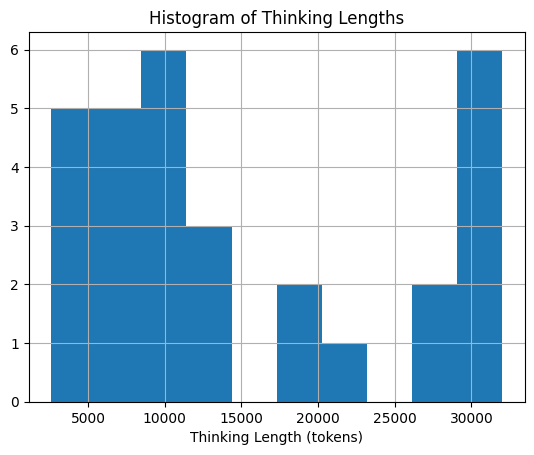

In [10]:
# Generate histogram of thinking lengths

print(results_df["thinking_tokens"].describe())
results_df["thinking_tokens"].hist()
plt.title("Histogram of Thinking Lengths")
plt.xlabel("Thinking Length (tokens)")
plt.show()

### Extra Credit: Prompt with Repetition

In [11]:
repetition_filepath = f"results_df_repetition_{MAX_NEW_TOKENS}_no_think"

In [ ]:
prompts = prompts_repeated

# Greedy decoding
sampling_params = SamplingParams(max_tokens=MAX_NEW_TOKENS, temperature=0.0)

outputs = model.generate(prompts, sampling_params)
model_outputs = [output.outputs[0].text for output in outputs]

records = get_records(dataset, model_outputs)

results_df = pd.DataFrame(records)
results_df

In [ ]:
# Save results for prompt with repetition

results_df.to_csv(f"{repetition_filepath}.csv", index=False)

In [12]:
# Load results for prompt with repetition

results_df = pd.read_csv(f"{repetition_filepath}.csv")
print(f"exact_correct accuracy: {results_df['exact_correct'].mean()}")
print(f"flexible_correct accuracy: {results_df['flexible_correct'].mean()}")

exact_correct accuracy: 0.23333333333333334
flexible_correct accuracy: 0.23333333333333334


## 2.2 Scaling Experiments

### Sequential

In [13]:
sequential_thinking_tokens_list = [1024, 2000, 4000, 8000, 16000, 28000, 32000]
sequential_filepath = "results_df_sequential"

In [ ]:
# This cell is for 2.2 scaling experiments (sequential). However, the next cell below has an optimized version.

for budget in sequential_thinking_tokens_list:
    records = []

    for i, example in enumerate(dataset):
        problem = example["prompt"][0]["content"]
        gold_answer = int(example["label"])

        prompt = prompts_think[i]

        model_output = generate_fixed_budget(model, tokenizer, prompt, budget)

        exact_extracted = extract_answer(model_output, mode="exact_match")
        flexible_extracted = extract_answer(model_output, mode="flexible_extract")
        exact_correct = (
            True
            if exact_extracted is not None and exact_extracted == gold_answer
            else False
        )
        flexible_correct = (
            True
            if flexible_extracted is not None and flexible_extracted == gold_answer
            else False
        )

        thinking_tokens = count_thinking_tokens(model_output)

        records.append(
            {
                "problem": problem,
                "gold_answer": gold_answer,
                "model_output": model_output,
                "exact_extracted": exact_extracted,
                "flexible_extracted": flexible_extracted,
                "exact_correct": exact_correct,
                "flexible_correct": flexible_correct,
                "thinking_tokens": thinking_tokens,
            }
        )

        print(
            f"[{i + 1}/{len(dataset)}] gold={gold_answer} exact_pred={exact_extracted} flexible_pred={flexible_extracted} exact_correct={exact_correct} flexible_correct={flexible_correct}"
        )

    results_df = pd.DataFrame(records)
    results_df.to_csv(f"results_df_sequential_{budget}.csv", index=False)

In [ ]:
# This cell is the optimized version for 2.2 sequential which uses batched prompts.

for budget in sequential_thinking_tokens_list:
    model_outputs = generate_fixed_budget_batched(
        model, tokenizer, prompts_think, budget
    )
    records = get_records(dataset, model_outputs)
    results_df = pd.DataFrame(records)
    results_df.to_csv(f"{sequential_filepath}_{budget}.csv", index=False)

In [14]:
# Compute sequential results

sequential_accs = {"exact": [], "flexible": []}
sequential_avg_tokens_list = []

for thinking_tokens in sequential_thinking_tokens_list:
    results_df = pd.read_csv(f"{sequential_filepath}_{thinking_tokens}.csv")
    sequential_accs["exact"].append(results_df["exact_correct"].mean())
    sequential_accs["flexible"].append(results_df["flexible_correct"].mean())
    sequential_avg_tokens_list.append(
        results_df["model_output"].apply(count_tokens).mean()
    )

### Parallel

In [15]:
parallel_budget = 4000
m = 8
parallel_filepath = "results_df_parallel"

In [ ]:
# This cell is the optimized version for 2.2 parallel which uses batched prompts.

for i in range(m):
    model_outputs = generate_fixed_budget_batched(
        model, tokenizer, prompts_think, parallel_budget
    )
    records = get_records(dataset, model_outputs, verbose=False)
    results_df = pd.DataFrame(records)
    results_df.to_csv(f"{parallel_filepath}_{i + 1}.csv", index=False)

In [16]:
def majority_vote(extracted_list):
    counts = Counter(extracted_list)
    return counts.most_common(1)[0][0]


def best_of_m(correct_list):
    return any(correct_list)


def combine_results(filepath, m):
    results_dfs = []

    for i in range(m):
        results_dfs.append(pd.read_csv(f"{filepath}_{i + 1}.csv"))

    return pd.DataFrame(
        {
            "problem": results_dfs[0]["problem"],
            "gold_answer": results_dfs[0]["gold_answer"],
            "model_output_list": list(
                zip(*[results_df["model_output"] for results_df in results_dfs])
            ),
            "exact_extracted_list": list(
                zip(*[results_df["exact_extracted"] for results_df in results_dfs])
            ),
            "flexible_extracted_list": list(
                zip(*[results_df["flexible_extracted"] for results_df in results_dfs])
            ),
            "exact_correct_list": list(
                zip(*[results_df["exact_correct"] for results_df in results_dfs])
            ),
            "flexible_correct_list": list(
                zip(*[results_df["flexible_correct"] for results_df in results_dfs])
            ),
            "thinking_tokens_list": list(
                zip(*[results_df["thinking_tokens"] for results_df in results_dfs])
            ),
        }
    )


def compute_parallel_results(combined_results_df, m_vals):
    parallel_accs = {
        "exact_majority": [],
        "flexible_majority": [],
        "exact_best_of_m": [],
        "flexible_best_of_m": [],
    }
    parallel_avg_tokens_list = []

    for m_val in m_vals:
        exact_majority_correct = []
        flexible_majority_correct = []
        exact_best_correct = []
        flexible_best_correct = []

        for _, row in combined_results_df.iterrows():
            gold_answer = row["gold_answer"]

            # Get first m completions
            exact_extracted_list = row["exact_extracted_list"][:m_val]
            flexible_extracted_list = row["flexible_extracted_list"][:m_val]
            exact_correct_list = row["exact_correct_list"][:m_val]
            flexible_correct_list = row["flexible_correct_list"][:m_val]

            # Majority vote
            exact_mv = majority_vote(exact_extracted_list)
            flexible_mv = majority_vote(flexible_extracted_list)
            exact_majority_correct.append(
                True if exact_mv is not None and exact_mv == gold_answer else False
            )
            flexible_majority_correct.append(
                True
                if flexible_mv is not None and flexible_mv == gold_answer
                else False
            )

            # Best of m
            exact_best_correct.append(best_of_m(exact_correct_list))
            flexible_best_correct.append(best_of_m(flexible_correct_list))

        parallel_accs["exact_majority"].append(np.mean(exact_majority_correct))
        parallel_accs["flexible_majority"].append(np.mean(flexible_majority_correct))
        parallel_accs["exact_best_of_m"].append(np.mean(exact_best_correct))
        parallel_accs["flexible_best_of_m"].append(np.mean(flexible_best_correct))
        parallel_avg_tokens_list.append(
            combined_results_df["model_output_list"]
            .apply(lambda outputs: sum(count_tokens(o) for o in outputs[:m_val]))
            .mean()
        )

    return parallel_accs, parallel_avg_tokens_list

In [17]:
# Combine the parallel results

combined_results_df = combine_results(parallel_filepath, m)
combined_results_df

,problem,gold_answer,model_output_list,exact_extracted_list,flexible_extracted_list,exact_correct_list,flexible_correct_list,thinking_tokens_list
0,Solve the following math problem step by step....,540,(<|im_start|>system\nYou are a careful competi...,"(540.0, 540.0, 540.0, 540.0, 540.0, 540.0, 540...","(540, 540, 540, 540, 540, 540, 540, 540)","(True, True, True, True, True, True, True, True)","(True, True, True, True, True, True, True, True)","(3999, 4000, 3999, 3999, 3999, 4000, 4000, 4000)"
1,Solve the following math problem step by step....,204,(<|im_start|>system\nYou are a careful competi...,"(204.0, 204.0, 204.0, 204.0, 204.0, 204.0, 204...","(204, 204, 204, 204, 204, 204, 204, 204)","(True, True, True, True, True, True, True, True)","(True, True, True, True, True, True, True, True)","(3999, 4000, 3999, 3999, 3999, 3999, 3998, 3998)"
2,Solve the following math problem step by step....,721,(<|im_start|>system\nYou are a careful competi...,"(721.0, 673.0, 721.0, 721.0, 721.0, 609.0, 337...","(721, 673, 721, 721, 721, 609, 337, 673)","(True, False, True, True, True, False, False, ...","(True, False, True, True, True, False, False, ...","(4000, 4000, 4000, 4000, 4000, 4000, 3999, 4000)"
3,Solve the following math problem step by step....,236,(<|im_start|>system\nYou are a careful competi...,"(nan, 232.0, 236.0, 236.0, nan, 302.0, 246.0, ...","(0, 232, 236, 236, 9, 302, 246, 201)","(False, False, True, True, False, False, False...","(False, False, True, True, False, False, False...","(4000, 3999, 4000, 4000, 3999, 3999, 4000, 4000)"
4,Solve the following math problem step by step....,809,(<|im_start|>system\nYou are a careful competi...,"(809.0, 578.0, 809.0, 809.0, 809.0, 1349.0, 80...","(809, 578, 809, 809, 809, 674, 809, 809)","(True, False, True, True, True, False, True, T...","(True, False, True, True, True, False, True, T...","(3999, 4000, 4000, 4000, 4000, 3999, 3999, 3999)"
5,Solve the following math problem step by step....,45,(<|im_start|>system\nYou are a careful competi...,"(100.0, 12475.0, nan, 45.0, 45.0, 45.0, 45.0, ...","(100, 4, 45, 45, 45, 45, 45, 100)","(False, False, False, True, True, True, True, ...","(False, False, True, True, True, True, True, F...","(3999, 4000, 4000, 3999, 4000, 3999, 4000, 4000)"
6,Solve the following math problem step by step....,385,(<|im_start|>system\nYou are a careful competi...,"(16.0, 16.0, nan, 24.0, 16.0, 12.0, nan, 12)","(16, 16, 3, 24, 16, 12, 1, 12)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 4000, 4000, 4000, 4000, 3999, 3999, 4000)"
7,Solve the following math problem step by step....,104,(<|im_start|>system\nYou are a careful competi...,"(80.0, nan, 107.0, 107.0, nan, nan, 107.0, 199)","(80, 2, 107, 107, 187, 905, 1, 199)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 3999, 3999, 4000, 4000, 4000, 4000, 3999)"
8,Solve the following math problem step by step....,601,(<|im_start|>system\nYou are a careful competi...,"(7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7)","(7, 7, 7, 7, 7, 7, 7, 7)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 3999, 3999, 4000, 3999, 4000, 4000, 3999)"
9,Solve the following math problem step by step....,23,(<|im_start|>system\nYou are a careful competi...,"(7.0, 43.0, 5.0, 5.0, 16.0, 5.0, 3.0, 23)","(7, 43, 5, 5, 16, 5, 3, 23)","(False, False, False, False, False, False, Fal...","(False, False, False, False, False, False, Fal...","(4000, 3999, 4000, 4000, 4000, 3999, 3999, 4000)"


In [ ]:
# Save the combined parallel results

combined_results_df.to_csv("results_df_parallel_combined.csv", index=False)

In [18]:
# Compute parallel results

m_vals = [1, 2, 4, 8]
parallel_thinking_tokens_list = [m_val * parallel_budget for m_val in m_vals]
parallel_accs, parallel_avg_tokens_list = compute_parallel_results(
    combined_results_df, m_vals
)

### Scaling Plots

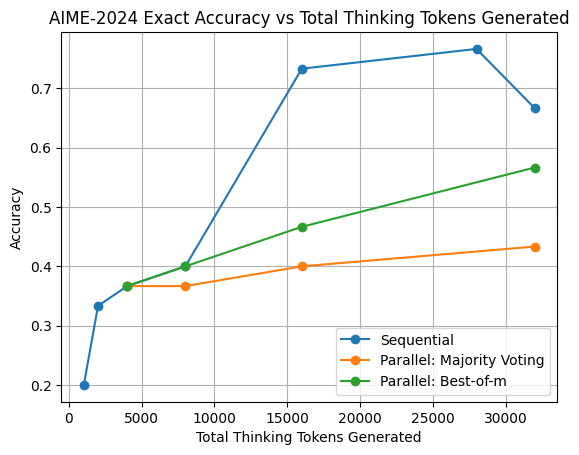

In [19]:
# Exact scaling plot

plt.figure()

plt.plot(
    sequential_thinking_tokens_list,
    sequential_accs["exact"],
    marker="o",
    label="Sequential",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["exact_majority"],
    marker="o",
    label="Parallel: Majority Voting",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["exact_best_of_m"],
    marker="o",
    label="Parallel: Best-of-m",
)

plt.xlabel("Total Thinking Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Exact Accuracy vs Total Thinking Tokens Generated")
plt.legend()
plt.grid()

plt.show()

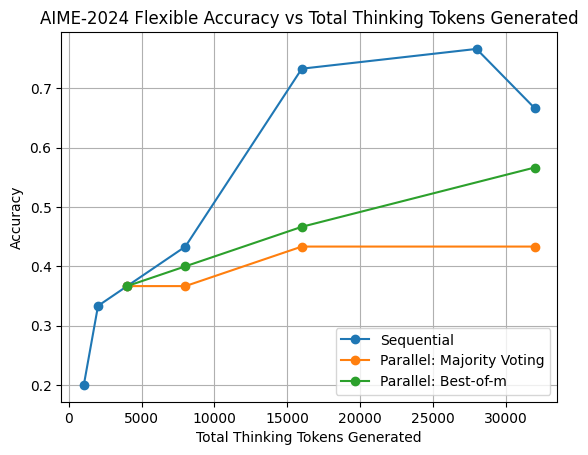

In [20]:
# Flexible scaling plot

plt.figure()

plt.plot(
    sequential_thinking_tokens_list,
    sequential_accs["flexible"],
    marker="o",
    label="Sequential",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["flexible_majority"],
    marker="o",
    label="Parallel: Majority Voting",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel: Best-of-m",
)

plt.xlabel("Total Thinking Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Flexible Accuracy vs Total Thinking Tokens Generated")
plt.legend()
plt.grid()

plt.show()

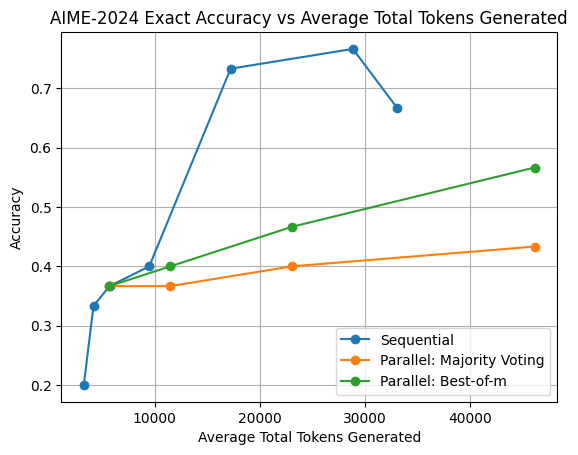

In [21]:
# Average tokens exact plot

plt.figure()

plt.plot(
    sequential_avg_tokens_list, sequential_accs["exact"], marker="o", label="Sequential"
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["exact_majority"],
    marker="o",
    label="Parallel: Majority Voting",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["exact_best_of_m"],
    marker="o",
    label="Parallel: Best-of-m",
)

plt.xlabel("Average Total Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Exact Accuracy vs Average Total Tokens Generated")
plt.legend()
plt.grid()

plt.show()

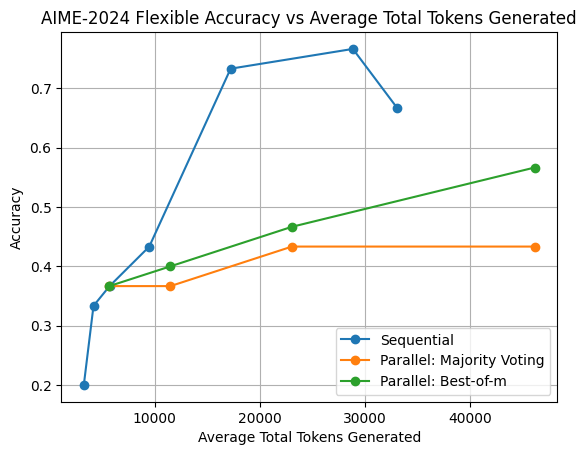

In [22]:
# Average tokens flexible plot

plt.figure()

plt.plot(
    sequential_avg_tokens_list,
    sequential_accs["flexible"],
    marker="o",
    label="Sequential",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["flexible_majority"],
    marker="o",
    label="Parallel: Majority Voting",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel: Best-of-m",
)

plt.xlabel("Average Total Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Flexible Accuracy vs Average Total Tokens Generated")
plt.legend()
plt.grid()

plt.show()

## 2.3 Qualitative Analysis

In [ ]:
# Qualitative analysis cell

temp_low_results_df_sequential = pd.read_csv("results_df_sequential_4000.csv")
temp_low_results_df_sequential

In [ ]:
# Qualitative analysis cell

temp_high_results_df_sequential = pd.read_csv("results_df_sequential_32000.csv")
temp_high_results_df_sequential

In [ ]:
# Qualitative analysis cell

combined_results_df

## 2.4 Improving Parallel Scaling

In [23]:
def generate_fixed_budgets(model, tokenizer, prompts, budgets, filepath):
    for i, budget in enumerate(budgets):
        model_outputs = generate_fixed_budget_batched(model, tokenizer, prompts, budget)
        records = get_records(dataset, model_outputs, verbose=False)
        results_df = pd.DataFrame(records)
        results_df.to_csv(f"{filepath}_{i + 1}.csv", index=False)


def generate_fixed_budget_batched_strat1(model, tokenizer, prompts, budget):
    prompts = [prompt + "<think>" for prompt in prompts]
    remaining_budget = budget - len(
        tokenizer.encode("<think>", add_special_tokens=False)
    )

    stop_token_ids = tokenizer.convert_tokens_to_ids(
        ["<think>", "</think>", "<|im_end|>"]
    )

    # Strategy 1: add presence penalty
    sampling_params = SamplingParams(
        max_tokens=remaining_budget,
        stop_token_ids=stop_token_ids,
        temperature=0.6,
        top_p=0.95,
        top_k=20,
        min_p=0.0,
        min_tokens=remaining_budget,
        presence_penalty=1.5,
    )

    outputs = model.generate(prompts, sampling_params)
    generated_texts = [output.outputs[0].text for output in outputs]
    prompts = [
        prompt + generated_texts[i] + "\n</think>" for i, prompt in enumerate(prompts)
    ]

    # Recommended sampling parameters on model card at https://huggingface.co/Qwen/Qwen3-4B
    final_answer_params = SamplingParams(
        max_tokens=4000, temperature=0.6, top_p=0.95, top_k=20, min_p=0.0
    )

    final_answer_outputs = model.generate(prompts, final_answer_params)
    generated_texts = [output.outputs[0].text for output in final_answer_outputs]
    prompts = [prompt + generated_texts[i] for i, prompt in enumerate(prompts)]
    return [extract_model_output(prompt) for prompt in prompts]


def generate_fixed_budgets_strat1(model, tokenizer, prompts, budgets, filepath):
    for i, budget in enumerate(budgets):
        model_outputs = generate_fixed_budget_batched_strat1(
            model, tokenizer, prompts, budget
        )
        records = get_records(dataset, model_outputs, verbose=False)
        results_df = pd.DataFrame(records)
        results_df.to_csv(f"{filepath}_{i + 1}.csv", index=False)

### Strategy 1: Adding a presence penalty when sampling

In [24]:
strat1_16000_budgets = [4000, 4000, 4000, 4000]
strat1_32000_budgets = [4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000]
strat1_16000_filepath = "results_df_strat1_16000"
strat1_32000_filepath = "results_df_strat1_32000"

In [ ]:
generate_fixed_budgets_strat1(
    model, tokenizer, prompts_think, strat1_16000_budgets, strat1_16000_filepath
)

In [ ]:
generate_fixed_budgets_strat1(
    model, tokenizer, prompts_think, strat1_32000_budgets, strat1_32000_filepath
)

In [25]:
strat1_16000_combined_results_df = combine_results(
    strat1_16000_filepath, len(strat1_16000_budgets)
)
strat1_32000_combined_results_df = combine_results(
    strat1_32000_filepath, len(strat1_32000_budgets)
)

strat1_16000_accs, strat1_16000_avg_tokens_list = compute_parallel_results(
    strat1_16000_combined_results_df, [len(strat1_16000_budgets)]
)
print(strat1_16000_accs)

strat1_32000_accs, strat1_32000_avg_tokens_list = compute_parallel_results(
    strat1_32000_combined_results_df, [len(strat1_32000_budgets)]
)
print(strat1_32000_accs)

{'exact_majority': [np.float64(0.43333333333333335)], 'flexible_majority': [np.float64(0.43333333333333335)], 'exact_best_of_m': [np.float64(0.5666666666666667)], 'flexible_best_of_m': [np.float64(0.5666666666666667)]}
{'exact_majority': [np.float64(0.5)], 'flexible_majority': [np.float64(0.5)], 'exact_best_of_m': [np.float64(0.6333333333333333)], 'flexible_best_of_m': [np.float64(0.6333333333333333)]}


In [26]:
strat1_accs = {
    "exact_majority": [],
    "flexible_majority": [],
    "exact_best_of_m": [],
    "flexible_best_of_m": [],
}
strat1_avg_tokens_list = []

strat1_accs["exact_majority"].extend(strat1_16000_accs["exact_majority"])
strat1_accs["flexible_majority"].extend(strat1_16000_accs["flexible_majority"])
strat1_accs["exact_best_of_m"].extend(strat1_16000_accs["exact_best_of_m"])
strat1_accs["flexible_best_of_m"].extend(strat1_16000_accs["flexible_best_of_m"])
strat1_avg_tokens_list.extend(strat1_16000_avg_tokens_list)

strat1_accs["exact_majority"].extend(strat1_32000_accs["exact_majority"])
strat1_accs["flexible_majority"].extend(strat1_32000_accs["flexible_majority"])
strat1_accs["exact_best_of_m"].extend(strat1_32000_accs["exact_best_of_m"])
strat1_accs["flexible_best_of_m"].extend(strat1_32000_accs["flexible_best_of_m"])
strat1_avg_tokens_list.extend(strat1_32000_avg_tokens_list)

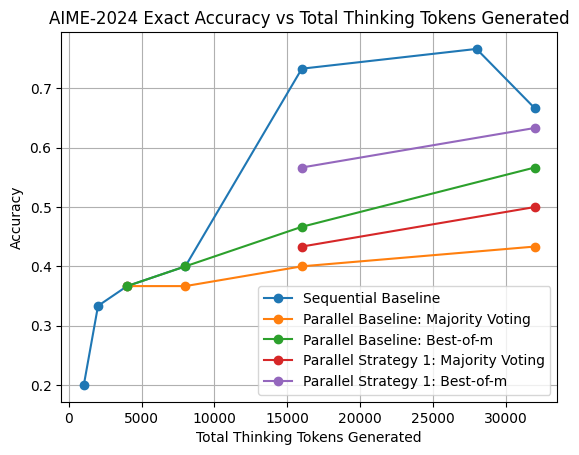

In [27]:
# Exact scaling plot

plt.figure()

plt.plot(
    sequential_thinking_tokens_list,
    sequential_accs["exact"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["exact_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    [16000, 32000],
    strat1_accs["exact_majority"],
    marker="o",
    label="Parallel Strategy 1: Majority Voting",
)
plt.plot(
    [16000, 32000],
    strat1_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Strategy 1: Best-of-m",
)

plt.xlabel("Total Thinking Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Exact Accuracy vs Total Thinking Tokens Generated")
plt.legend()
plt.grid()

plt.show()

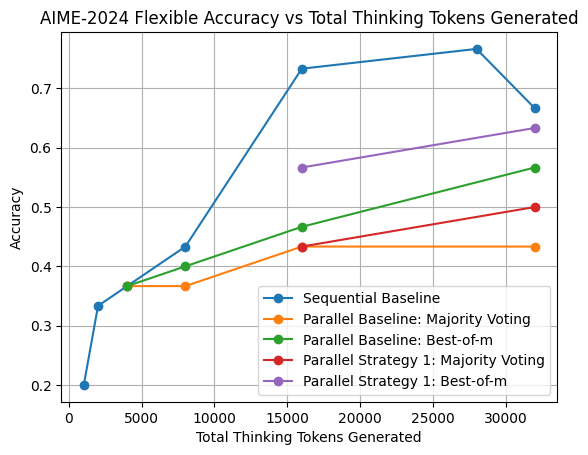

In [28]:
# Flexible scaling plot

plt.figure()

plt.plot(
    sequential_thinking_tokens_list,
    sequential_accs["flexible"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["flexible_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    [16000, 32000],
    strat1_accs["flexible_majority"],
    marker="o",
    label="Parallel Strategy 1: Majority Voting",
)
plt.plot(
    [16000, 32000],
    strat1_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Strategy 1: Best-of-m",
)

plt.xlabel("Total Thinking Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Flexible Accuracy vs Total Thinking Tokens Generated")
plt.legend()
plt.grid()

plt.show()

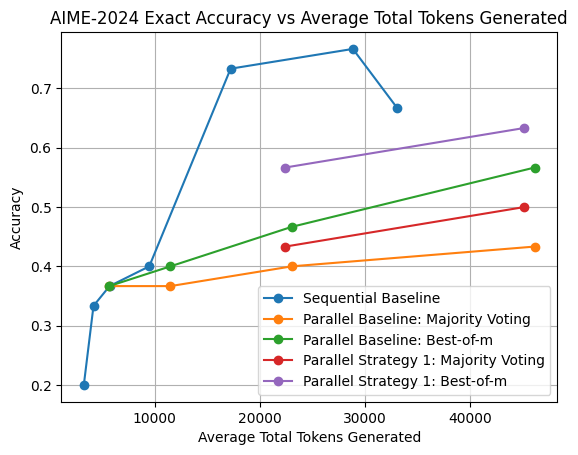

In [29]:
# Average tokens exact plot

plt.figure()

plt.plot(
    sequential_avg_tokens_list,
    sequential_accs["exact"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["exact_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    strat1_avg_tokens_list,
    strat1_accs["exact_majority"],
    marker="o",
    label="Parallel Strategy 1: Majority Voting",
)
plt.plot(
    strat1_avg_tokens_list,
    strat1_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Strategy 1: Best-of-m",
)

plt.xlabel("Average Total Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Exact Accuracy vs Average Total Tokens Generated")
plt.legend()
plt.grid()

plt.show()

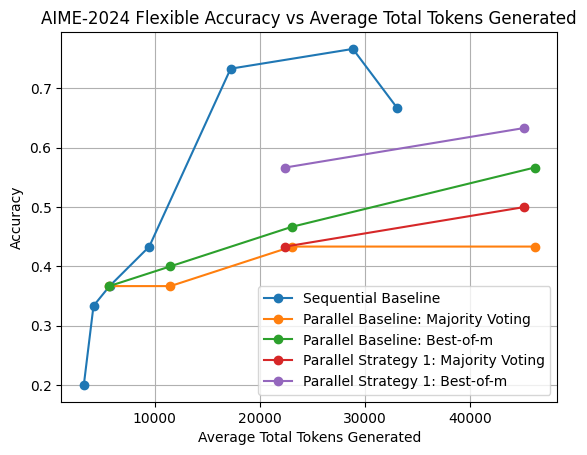

In [30]:
# Average tokens flexible plot

plt.figure()

plt.plot(
    sequential_avg_tokens_list,
    sequential_accs["flexible"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["flexible_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    strat1_avg_tokens_list,
    strat1_accs["flexible_majority"],
    marker="o",
    label="Parallel Strategy 1: Majority Voting",
)
plt.plot(
    strat1_avg_tokens_list,
    strat1_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Strategy 1: Best-of-m",
)

plt.xlabel("Average Total Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Flexible Accuracy vs Average Total Tokens Generated")
plt.legend()
plt.grid()

plt.show()

### Strategy 2: Varied thinking budgets

In [53]:
strat2_16000_budgets = [3000, 4000, 4000, 5000]
strat2_32000_budgets = [2000, 4000, 5000, 6000, 7000, 8000]
strat2_16000_filepath = "results_df_strat2_16000"
strat2_32000_filepath = "results_df_strat2_32000"

In [ ]:
generate_fixed_budgets(
    model, tokenizer, prompts_think, strat2_16000_budgets, strat2_16000_filepath
)

In [ ]:
generate_fixed_budgets(
    model, tokenizer, prompts_think, strat2_32000_budgets, strat2_32000_filepath
)

In [54]:
strat2_16000_combined_results_df = combine_results(
    strat2_16000_filepath, len(strat2_16000_budgets)
)
strat2_32000_combined_results_df = combine_results(
    strat2_32000_filepath, len(strat2_32000_budgets)
)

strat2_16000_accs, strat2_16000_avg_tokens_list = compute_parallel_results(
    strat2_16000_combined_results_df, [len(strat2_16000_budgets)]
)
print(strat2_16000_accs)

strat2_32000_accs, strat2_32000_avg_tokens_list = compute_parallel_results(
    strat2_32000_combined_results_df, [len(strat2_32000_budgets)]
)
print(strat2_32000_accs)

{'exact_majority': [np.float64(0.36666666666666664)], 'flexible_majority': [np.float64(0.36666666666666664)], 'exact_best_of_m': [np.float64(0.5666666666666667)], 'flexible_best_of_m': [np.float64(0.5666666666666667)]}
{'exact_majority': [np.float64(0.5333333333333333)], 'flexible_majority': [np.float64(0.5333333333333333)], 'exact_best_of_m': [np.float64(0.7)], 'flexible_best_of_m': [np.float64(0.7)]}


In [55]:
strat2_accs = {
    "exact_majority": [],
    "flexible_majority": [],
    "exact_best_of_m": [],
    "flexible_best_of_m": [],
}
strat2_avg_tokens_list = []

strat2_accs["exact_majority"].extend(strat2_16000_accs["exact_majority"])
strat2_accs["flexible_majority"].extend(strat2_16000_accs["flexible_majority"])
strat2_accs["exact_best_of_m"].extend(strat2_16000_accs["exact_best_of_m"])
strat2_accs["flexible_best_of_m"].extend(strat2_16000_accs["flexible_best_of_m"])
strat2_avg_tokens_list.extend(strat2_16000_avg_tokens_list)

strat2_accs["exact_majority"].extend(strat2_32000_accs["exact_majority"])
strat2_accs["flexible_majority"].extend(strat2_32000_accs["flexible_majority"])
strat2_accs["exact_best_of_m"].extend(strat2_32000_accs["exact_best_of_m"])
strat2_accs["flexible_best_of_m"].extend(strat2_32000_accs["flexible_best_of_m"])
strat2_avg_tokens_list.extend(strat2_32000_avg_tokens_list)

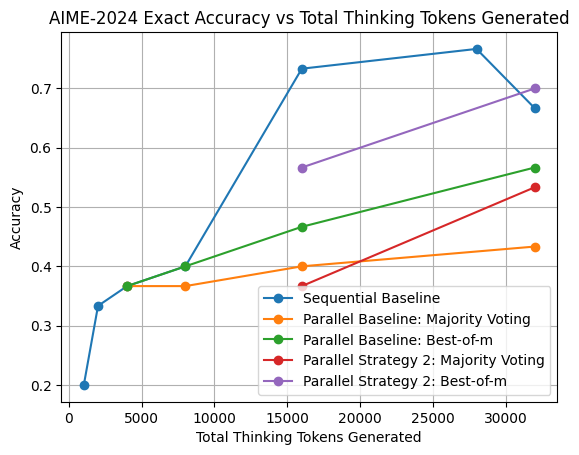

In [56]:
# Exact scaling plot

plt.figure()

plt.plot(
    sequential_thinking_tokens_list,
    sequential_accs["exact"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["exact_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    [16000, 32000],
    strat2_accs["exact_majority"],
    marker="o",
    label="Parallel Strategy 2: Majority Voting",
)
plt.plot(
    [16000, 32000],
    strat2_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Strategy 2: Best-of-m",
)

plt.xlabel("Total Thinking Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Exact Accuracy vs Total Thinking Tokens Generated")
plt.legend()
plt.grid()

plt.show()

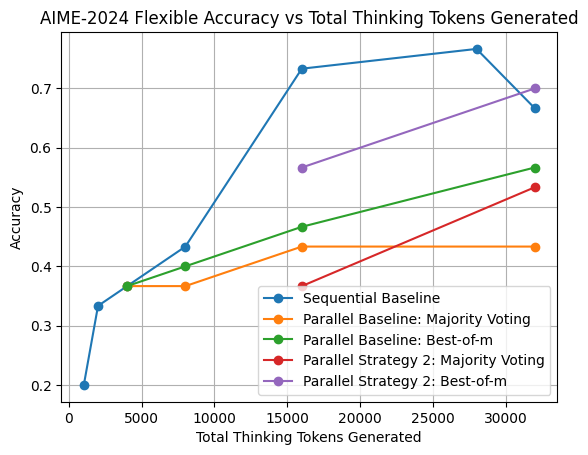

In [57]:
# Flexible scaling plot

plt.figure()

plt.plot(
    sequential_thinking_tokens_list,
    sequential_accs["flexible"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["flexible_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_thinking_tokens_list,
    parallel_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    [16000, 32000],
    strat2_accs["flexible_majority"],
    marker="o",
    label="Parallel Strategy 2: Majority Voting",
)
plt.plot(
    [16000, 32000],
    strat2_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Strategy 2: Best-of-m",
)

plt.xlabel("Total Thinking Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Flexible Accuracy vs Total Thinking Tokens Generated")
plt.legend()
plt.grid()

plt.show()

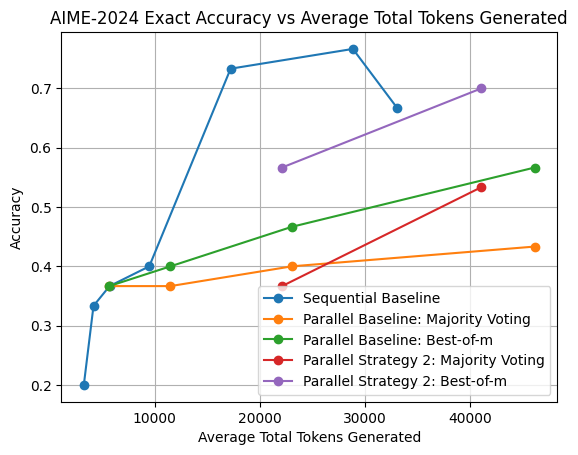

In [58]:
# Average tokens exact plot

plt.figure()

plt.plot(
    sequential_avg_tokens_list,
    sequential_accs["exact"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["exact_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    strat2_avg_tokens_list,
    strat2_accs["exact_majority"],
    marker="o",
    label="Parallel Strategy 2: Majority Voting",
)
plt.plot(
    strat2_avg_tokens_list,
    strat2_accs["exact_best_of_m"],
    marker="o",
    label="Parallel Strategy 2: Best-of-m",
)

plt.xlabel("Average Total Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Exact Accuracy vs Average Total Tokens Generated")
plt.legend()
plt.grid()

plt.show()

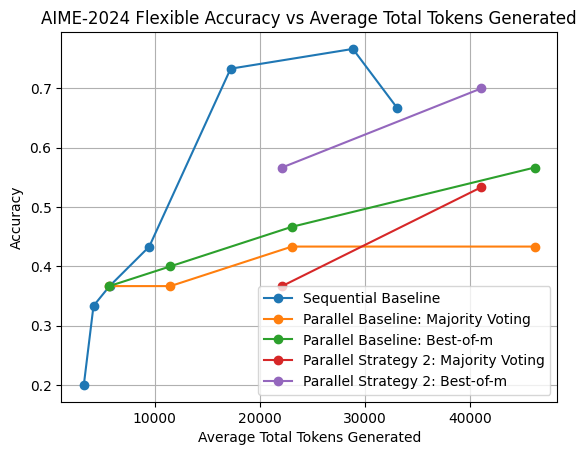

In [59]:
# Average tokens flexible plot

plt.figure()

plt.plot(
    sequential_avg_tokens_list,
    sequential_accs["flexible"],
    marker="o",
    label="Sequential Baseline",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["flexible_majority"],
    marker="o",
    label="Parallel Baseline: Majority Voting",
)
plt.plot(
    parallel_avg_tokens_list,
    parallel_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Baseline: Best-of-m",
)
plt.plot(
    strat2_avg_tokens_list,
    strat2_accs["flexible_majority"],
    marker="o",
    label="Parallel Strategy 2: Majority Voting",
)
plt.plot(
    strat2_avg_tokens_list,
    strat2_accs["flexible_best_of_m"],
    marker="o",
    label="Parallel Strategy 2: Best-of-m",
)

plt.xlabel("Average Total Tokens Generated")
plt.ylabel("Accuracy")
plt.title("AIME-2024 Flexible Accuracy vs Average Total Tokens Generated")
plt.legend()
plt.grid()

plt.show()